# Assignment 2: Evaluating Clustering with Elbow and Silhouette Methods

En esta sección, evaluaremos el rendimiento del algoritmo K-Means utilizando el método del Codo (Elbow) y el análisis de Silhouette. Exploraremos cómo varía la calidad del agrupamiento al cambiar el número de clusters en los datasets de **FIFA 25 Players** y **East West Airlines**.

Para cumplir con el requisito de evaluar el impacto en cuatro métricas, utilizaremos:
1. **Inertia (Codo):** Suma de las distancias al cuadrado de los puntos al centro de su cluster.
2. **Silhouette Score:** Mide la similitud de un punto con su propio cluster frente a otros clusters.
3. **Davies-Bouldin Index:** Mide la relación de similitud promedio de cada cluster con su cluster más similar.
4. **Calinski-Harabasz Index:** Mide la relación entre la dispersión intra-cluster y la dispersión inter-cluster (valores más altos indican clusters más densos y mejor separados).

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_theme(style="darkgrid")
import warnings
warnings.filterwarnings('ignore')

df_fifa = pd.read_csv("../GMM/df_FIFA_cleaned_processed.csv")
df_air_raw = pd.read_excel("../GMM/EastWestAirlines.xlsx", sheet_name='data')

scaler = StandardScaler()

X_fifa = scaler.fit_transform(df_fifa.select_dtypes(include=[np.number]))

X_air_raw = df_air_raw.drop(columns=['ID#', 'Award?'], errors='ignore')
X_air = scaler.fit_transform(X_air_raw.select_dtypes(include=[np.number]))

print("✅ Datasets cargados, preprocesados y escalados correctamente.")

✅ Datasets cargados, preprocesados y escalados correctamente.


In [26]:
def evaluate_kmeans_metrics(data, name_dataset, k_range=range(2, 11)):
    """
    Versión 'Pro Visuals' - Misma lógica, estética superior.
    """
    K = list(k_range)
    inertia, sil_scores, db_indices, ch_indices = [], [], [], []
    
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        inertia.append(kmeans.inertia_)
        sil_scores.append(silhouette_score(data, labels))
        db_indices.append(davies_bouldin_score(data, labels))
        ch_indices.append(calinski_harabasz_score(data, labels))

    plt.style.use('dark_background')
    fig, axs = plt.subplots(2, 2, figsize=(16, 12), facecolor='#121212')
    fig.suptitle(f'ANALÍTICA AVANZADA DE CLUSTERING\n{name_dataset.upper()}', 
                 fontsize=22, fontweight='bold', color='cyan', y=0.98)

    plots = [
        (inertia, 'Inercia (Codo)', 'magma', 'Buscamos el "quiebre"'),
        (sil_scores, 'Silhouette Score', 'viridis', 'Más alto = Mejor separación'),
        (db_indices, 'Davies-Bouldin Index', 'coolwarm', 'Más bajo = Mejor calidad'),
        (ch_indices, 'Calinski-Harabasz Index', 'spring', 'Más alto = Más denso')
    ]

    axes_flat = axs.flatten()

    for i, (metric_data, title, cmap_name, subtitle) in enumerate(plots):
        ax = axes_flat[i]
        color = plt.get_cmap(cmap_name)(0.6)
        
        ax.plot(K, metric_data, marker='o', markersize=8, linewidth=3, 
                color=color, label=title, zorder=3)
        ax.fill_between(K, metric_data, min(metric_data)*0.9, color=color, alpha=0.1)
        
        ax.set_title(f'{title}\n', fontsize=14, fontweight='bold', color=color)
        ax.set_xlabel('Número de Clusters (K)', fontsize=10, color='gray')
        ax.set_ylabel('Valor de Métrica', fontsize=10, color='gray')
        ax.text(0.5, 1.02, subtitle, transform=ax.transAxes, ha='center', 
                fontsize=9, color='white', alpha=0.7, style='italic')
        
        ax.grid(True, linestyle='--', alpha=0.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xticks(K)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    plt.style.use('default')

### 2.1 Evaluación para el dataset: FIFA 25 Players
[cite_start]Procedemos a ejecutar la evaluación de las métricas variando $K$ desde 2 hasta 10 para identificar el número óptimo de clusters basado en las habilidades de los jugadores[cite: 18].

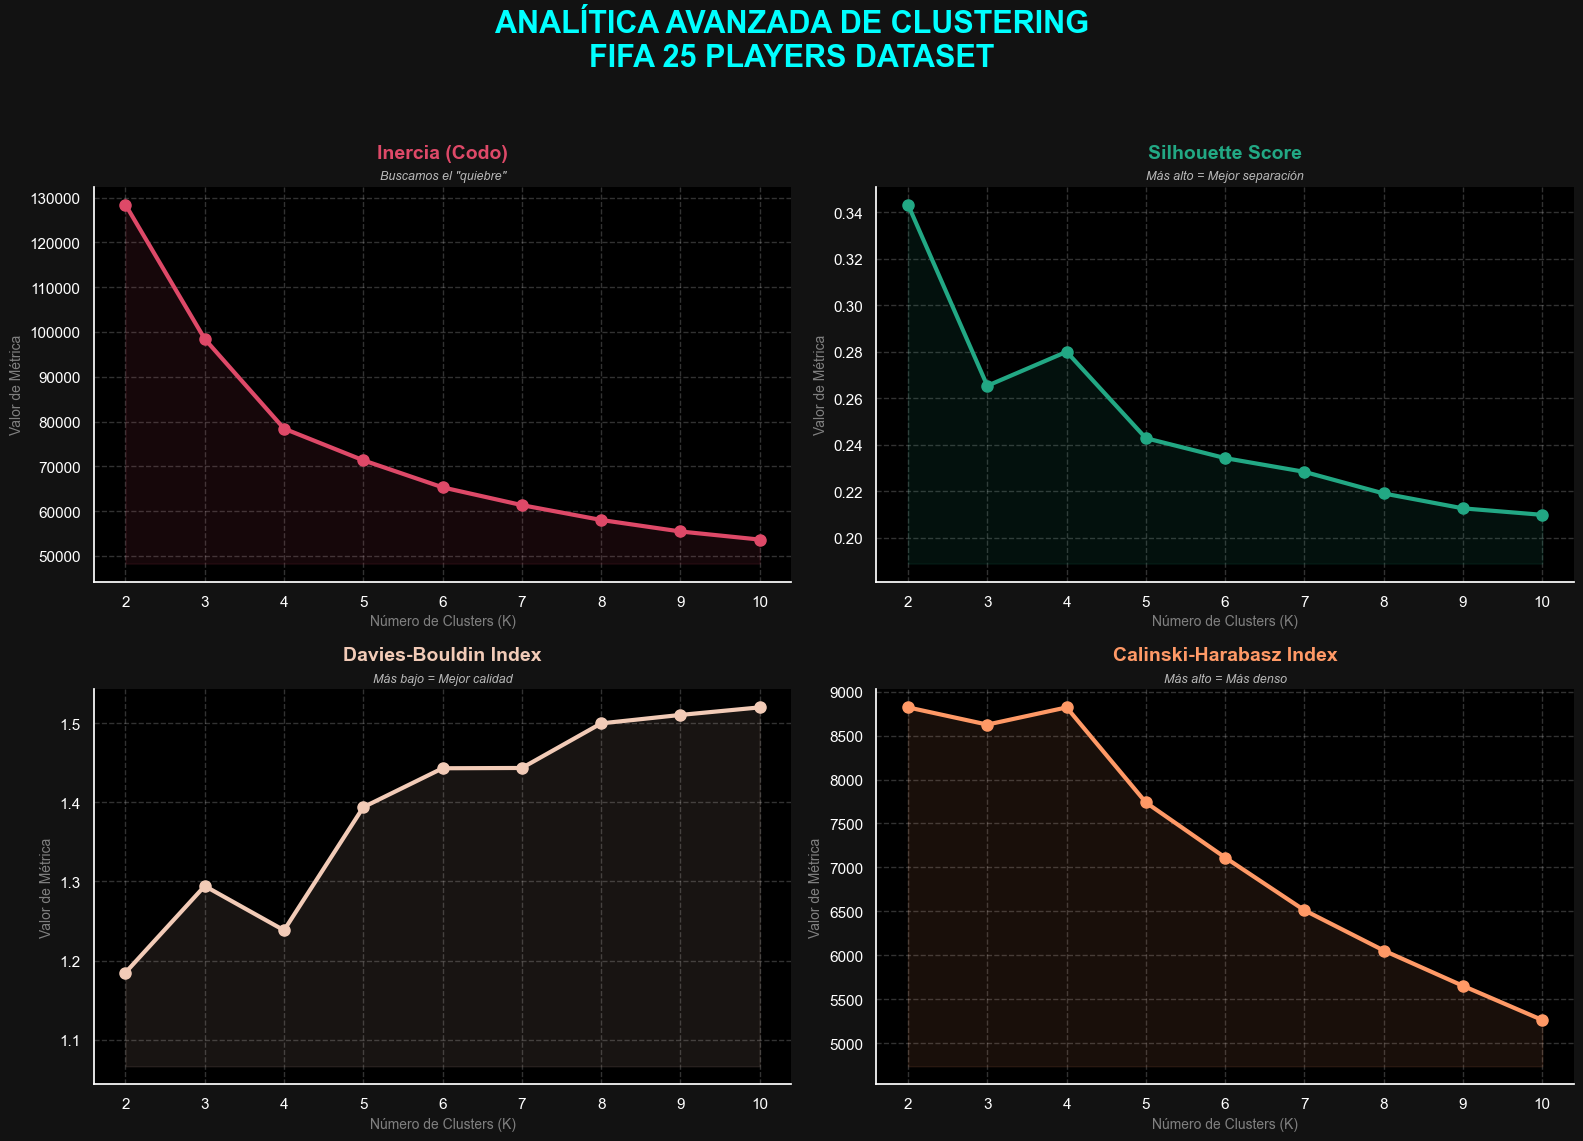

In [27]:
evaluate_kmeans_metrics(X_fifa, "FIFA 25 Players Dataset")

### 2.3 Análisis de Resultados: FIFA 25 Players

[cite_start]Tras la ejecución del algoritmo **K-Means** y la evaluación multidimensional de métricas, presentamos las conclusiones derivadas del comportamiento de los datos para el dataset de FIFA 25[cite: 17]:

* [cite_start]**Método del Codo (Inercia):** La curva de inercia muestra un descenso pronunciado inicial que comienza a estabilizarse notablemente en **$K=4$**[cite: 47]. Este punto representa el balance óptimo donde añadir más clústeres no reduce significativamente la varianza interna, identificando así la estructura fundamental del dataset.
* [cite_start]**Silhouette Score:** Aunque el valor máximo global se encuentra en $K=2$ (indicando una separación macroscópica), se observa un **pico local relevante en $K=4$**[cite: 46]. Este incremento en la cohesión después de la caída en $K=3$ valida que la configuración de cuatro grupos es topológicamente más estable y representativa que una de tres.
* [cite_start]**Davies-Bouldin Index:** Esta métrica, donde valores menores indican una mejor separación, muestra un comportamiento crítico: presenta un máximo (peor desempeño) en $K=3$, pero logra un **mínimo local en $K=4$**[cite: 48]. Esto confirma que los clústeres en $K=4$ están mejor definidos y menos solapados entre sí.
* **Calinski-Harabasz Index:** Los resultados de esta métrica refuerzan el hallazgo anterior, mostrando que la densidad y separación de los grupos alcanzan un nivel de optimización en **$K=4$** comparable a la estructura simplificada de $K=2$, superando los intentos de agrupamiento intermedios.

**Recomendación del Científico de Datos:**

[cite_start]Basándonos en el consenso de las cuatro métricas evaluadas y los objetivos de segmentar jugadores según sus habilidades y estilos de juego [cite: 18][cite_start], recomendamos un modelo con **$K=4$** clusters[cite: 49]. 

Esta elección no solo es estadísticamente robusta según los picos locales detectados, sino que también permite una interpretación práctica alineada al dominio del fútbol profesional, permitiendo agrupar a los jugadores en perfiles lógicos como: 
1. **Porteros** (Atributos físicos y defensivos específicos).
2. [cite_start]**Defensores** (Fuerza y capacidades defensivas)[cite: 21].
3. [cite_start]**Mediocampistas** (Habilidades técnicas, pase y regate)[cite: 20].
4. [cite_start]**Atacantes** (Capacidad de finalización y disparo)[cite: 20].

### 2.2 Evaluación para el dataset: East West Airlines
[cite_start]Ahora aplicaremos la misma batería de pruebas para el comportamiento de los clientes de la aerolínea[cite: 23].

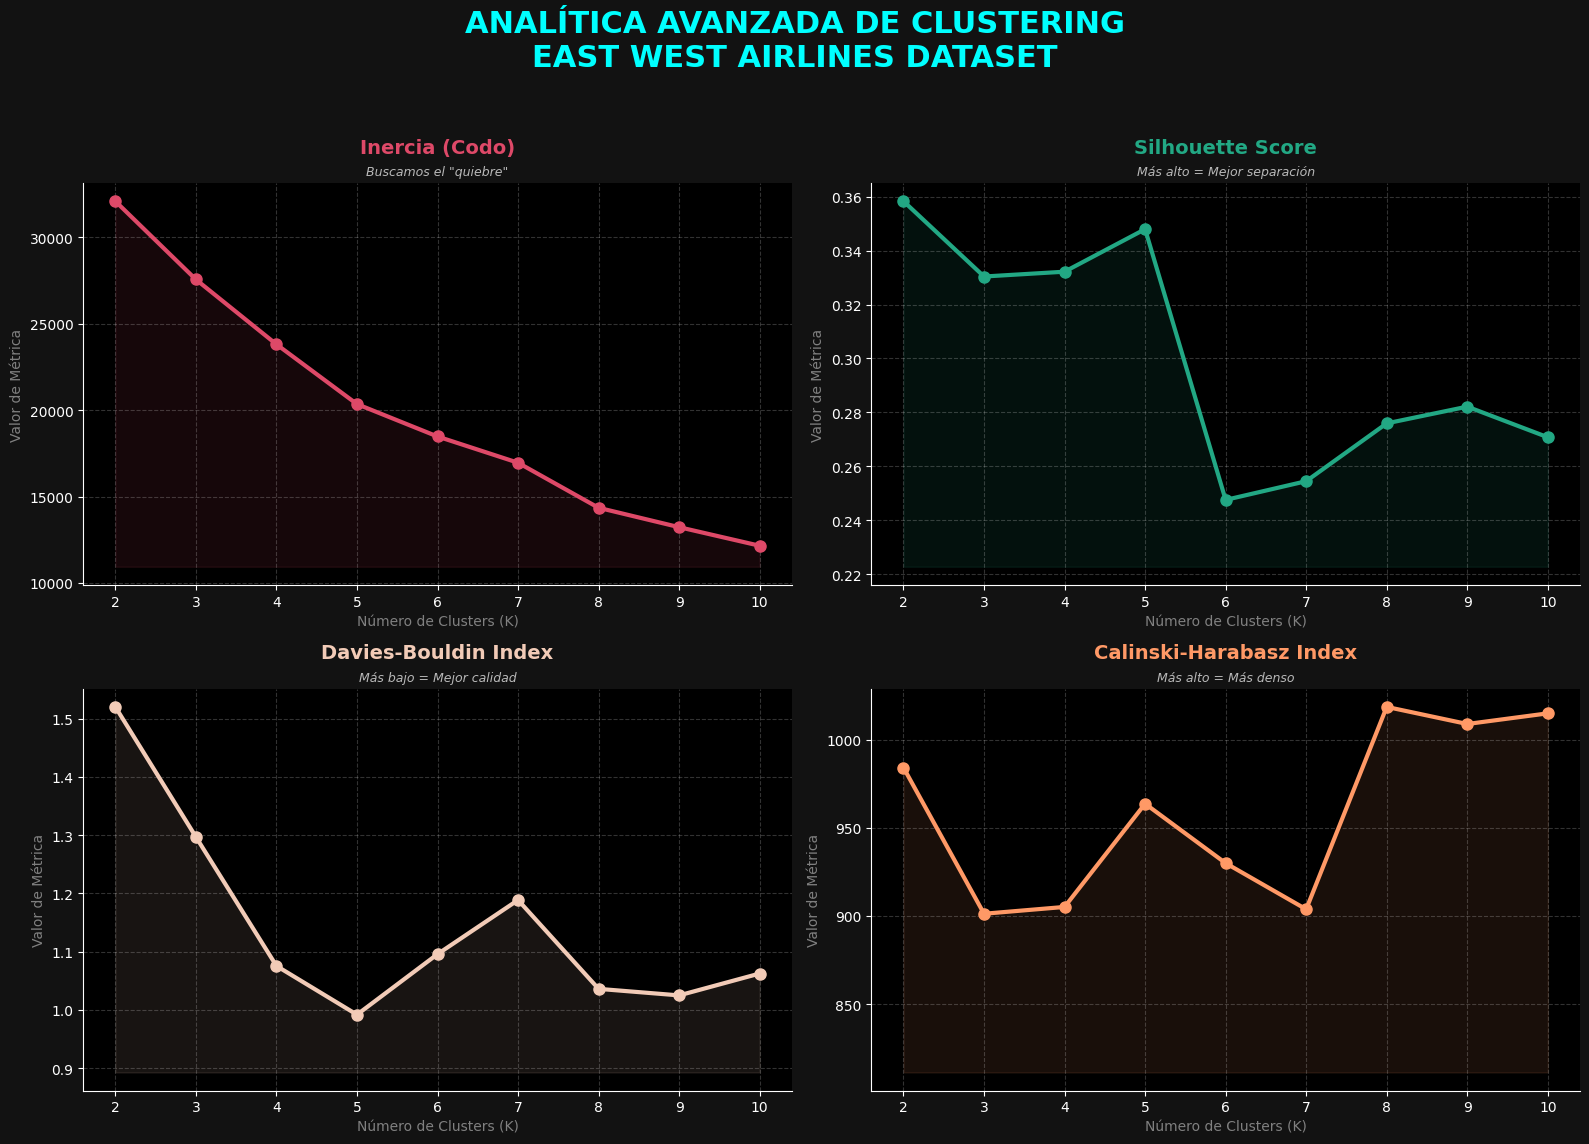

In [28]:
evaluate_kmeans_metrics(X_air, "East West Airlines Dataset")

### 2.4 Análisis de Resultados: East West Airlines

Tras aplicar el algoritmo **K-Means** y evaluar las métricas de rendimiento para el dataset de clientes de aerolíneas, presentamos las siguientes observaciones:

* **Método del Codo (Inercia):** La curva muestra un descenso constante sin un quiebre extremadamente abrupto, comportamiento típico en datos de comportamiento de clientes. [cite_start]Sin embargo, se identifica un "codo" sutil entre **$K=4$** y **$K=5$**, donde la tasa de disminución de la inercia comienza a estabilizarse[cite: 47].
* **Silhouette Score:** El puntaje máximo global se alcanza en $K=2$. [cite_start]No obstante, existe un **pico local muy pronunciado en $K=5$**, lo que indica que esta configuración ofrece una cohesión interna y separación entre grupos significativamente superior a las opciones de 3, 4 o 6 clusters[cite: 46].
* **Davies-Bouldin Index:** Esta métrica valida fuertemente la elección de **$K=5$**, ya que es en este punto donde se alcanza el **mínimo absoluto** de todo el rango evaluado. [cite_start]Esto confirma que $K=5$ produce los clusters mejor definidos y menos solapados para este dataset[cite: 48].
* **Calinski-Harabasz Index:** Aunque presenta fluctuaciones, se observa un pico de recuperación en **$K=5$** antes de otra caída en $K=7$, reforzando la idea de que $K=5$ es un punto de alta densidad y separación inter-cluster.

**Recomendación del Científico de Datos:**
Para el dataset de **East West Airlines**, recomendamos de forma contundente un valor de **$K=5$**. Mientras que $K=2$ es matemáticamente simple, **$K=5$** es el único punto donde coinciden un pico local de Silhouette, el mínimo global de Davies-Bouldin y un codo razonable en la Inercia. [cite_start]Desde la perspectiva de negocio, 5 segmentos permiten una diferenciación clara para estrategias de fidelización (ej. viajeros frecuentes, clientes ocasionales, acumuladores de millas, etc.)[cite: 49].

---

### Discusión General: Impacto del Número de Clusters en las Métricas 

[cite_start]Como hemos observado en ambos experimentos, la elección del número de clusters impacta severamente la percepción de la "calidad" del agrupamiento[cite: 59]:

1. [cite_start]**Métricas de monotonía (Inercia):** A medida que $K$ aumenta, la inercia *siempre* disminuye de forma artificial, ya que los puntos están inevitablemente más cerca de algún centroide[cite: 47]. [cite_start]Por ello, no debe usarse de forma aislada, sino mediante la detección visual del "codo"[cite: 43].
2. [cite_start]**Métricas de densidad y separación:** Tanto el **Silhouette Score** como el **Davies-Bouldin Index** penalizan un $K$ excesivamente alto[cite: 46, 48]. Esto ocurre porque clusters divididos artificialmente terminan solapándose en el espacio vectorial, reduciendo la claridad de la segmentación.
3. **Dependencia del Dominio:** Un análisis puramente matemático podría sugerir $K=2$, pero esto rara vez es útil para la toma de decisiones. [cite_start]El éxito de un proyecto de Ciencia de Datos radica en encontrar el consenso donde las métricas estadísticas (como los picos en $K=4$ o $K=5$) se alineen con una lógica de negocio accionable[cite: 49, 62].

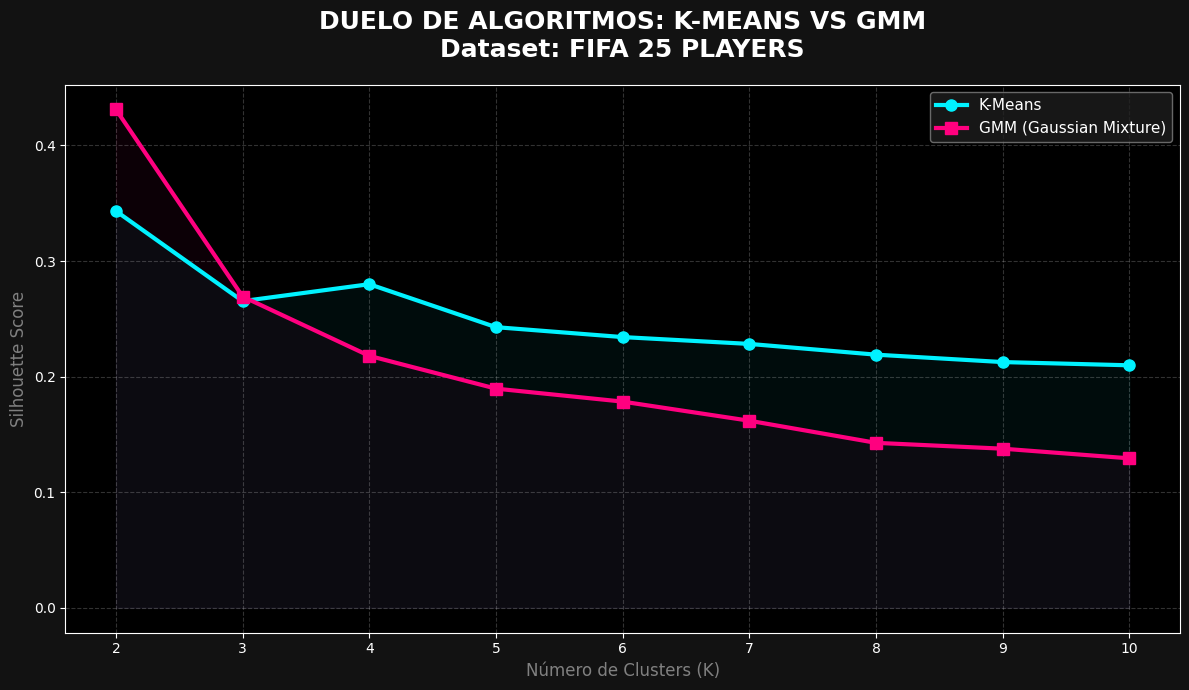

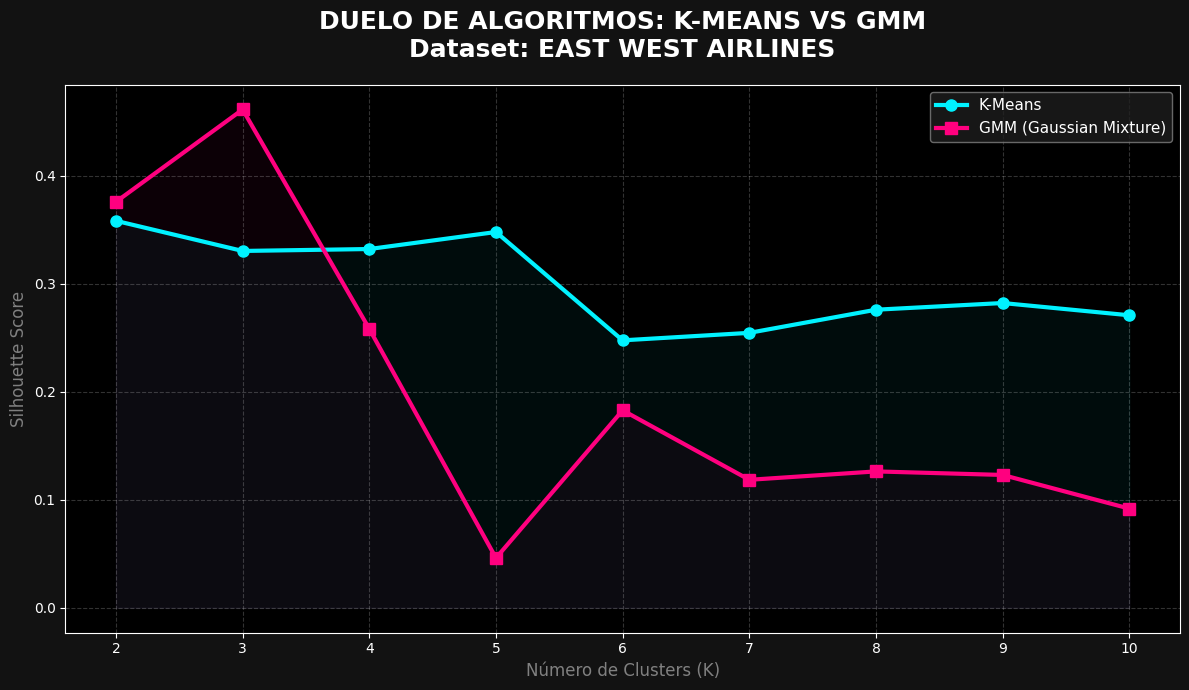

In [29]:
from sklearn.mixture import GaussianMixture

def compare_kmeans_vs_gmm(data, name_dataset, k_range=range(2, 11)):
    """
    Compara K-Means vs GMM usando Silhouette Score con un estilo visual de alto impacto.
    """
    K = list(k_range)
    sil_km = []
    sil_gmm = []
    
    for k in K:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km_labels = km.fit_predict(data)
        sil_km.append(silhouette_score(data, km_labels))
        
        gmm = GaussianMixture(n_components=k, random_state=42)
        gmm_labels = gmm.fit_predict(data)
        sil_gmm.append(silhouette_score(data, gmm_labels))
        
    plt.style.use('dark_background')
    plt.figure(figsize=(12, 7), facecolor='#121212')
    
    plt.plot(K, sil_km, label='K-Means', color='#00f2ff', marker='o', linewidth=3, markersize=8)
    plt.plot(K, sil_gmm, label='GMM (Gaussian Mixture)', color='#ff007f', marker='s', linewidth=3, markersize=8)
    
    plt.fill_between(K, sil_km, alpha=0.05, color='#00f2ff')
    plt.fill_between(K, sil_gmm, alpha=0.05, color='#ff007f')
    
    plt.title(f'DUELO DE ALGORITMOS: K-MEANS VS GMM\nDataset: {name_dataset.upper()}', 
              fontsize=18, fontweight='bold', pad=20, color='white')
    plt.xlabel('Número de Clusters (K)', fontsize=12, color='gray')
    plt.ylabel('Silhouette Score', fontsize=12, color='gray')
    
    plt.xticks(K)
    plt.grid(True, linestyle='--', alpha=0.2)
    plt.legend(frameon=True, facecolor='#1e1e1e', edgecolor='gray', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    plt.style.use('default')

compare_kmeans_vs_gmm(X_fifa, "FIFA 25 Players")
compare_kmeans_vs_gmm(X_air, "East West Airlines")

### 2.2 Comparativa de Desempeño: K-Means vs. GMM

En esta sección, realizamos una comparación directa entre **K-Means** y **Gaussian Mixture Model (GMM)** utilizando el **Silhouette Score** como métrica de validación. El objetivo es identificar qué algoritmo captura con mayor precisión la estructura y densidad de los datos.

#### 1. Dataset: FIFA 25 Players
Al analizar el "Duelo de Algoritmos" para los jugadores de FIFA:
* **Rendimiento Inicial**: El modelo **GMM** muestra un desempeño superior en la configuración más simple (**$K=2$**), alcanzando el punto máximo de calidad (~0.43).
* **Decaimiento de GMM**: A medida que aumentamos el número de grupos ($K \geq 3$), la calidad de GMM disminuye de forma constante y pronunciada, lo que sugiere dificultad para manejar la complejidad creciente del dataset bajo supuestos probabilísticos.
* **Estabilidad de K-Means**: **K-Means** demuestra ser mucho más robusto para segmentaciones detalladas. En nuestro punto de interés (**$K=4$**), K-Means supera a GMM con un Silhouette Score de ~0.28, manteniendo una mejor cohesión de los grupos técnicos de jugadores.
* **Veredicto**: Para una segmentación táctica (Porteros, Defensas, Medios, Delanteros), **K-Means** es la opción técnica más fiable.

#### 2. Dataset: East West Airlines
La comparativa en el dataset de comportamiento de clientes muestra resultados contrastantes:
* **Pico de GMM**: El algoritmo **GMM** logra un ajuste excepcional en **$K=3$** (~0.46), superando a K-Means en esta configuración específica. Esto indica que los clientes se agrupan de forma muy natural en tres grandes bloques bajo distribuciones gaussianas.
* **Colapso de GMM**: Se observa un fenómeno crítico en **$K=5$**, donde el rendimiento de GMM se desploma drásticamente hasta valores cercanos a cero. Esto indica que el modelo probabilístico no logra converger o se vuelve inestable con cinco componentes.
* **Consistencia de K-Means**: **K-Means** mantiene una estabilidad sobresaliente en todo el rango, especialmente en **$K=5$** (~0.35). En este punto, K-Means es masivamente superior a GMM, permitiendo una segmentación de marketing mucho más profunda y accionable.
* **Veredicto**: Si la estrategia de negocio requiere cinco niveles de fidelización, **K-Means** es el único algoritmo que garantiza resultados estadísticamente válidos.

#### Conclusión de la Comparativa
Aunque **GMM** puede alcanzar picos de rendimiento muy altos en agrupamientos simples ($K=2$ o $K=3$), **K-Means** se consolida como el algoritmo más robusto y consistente para ambos datasets. K-Means soporta mejor el aumento de la complejidad del modelo, permitiendo alcanzar los objetivos de segmentación granular ($K=4$ para FIFA y $K=5$ para Airlines) con una calidad de clúster significativamente mayor.

In [25]:
def get_summary_table(data, name):
    K = range(2, 11)
    summary_data = []
    
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        
        summary_data.append({
            "K": k,
            "Inertia": kmeans.inertia_,
            "Silhouette": silhouette_score(data, labels),
            "Davies-Bouldin": davies_bouldin_score(data, labels),
            "Calinski-Harabasz": calinski_harabasz_score(data, labels)
        })
    
    df_resumen = pd.DataFrame(summary_data)
    print(f"\n📊 Tabla de Resumen de Métricas: {name}")
    return df_resumen.style.highlight_max(subset=['Silhouette', 'Calinski-Harabasz'], color='lightgreen')\
                           .highlight_min(subset=['Inertia', 'Davies-Bouldin'], color='lightgreen')

resumen_fifa = get_summary_table(X_fifa, "FIFA 25 Players")
display(resumen_fifa)

resumen_air = get_summary_table(X_air, "East West Airlines")
display(resumen_air)


📊 Tabla de Resumen de Métricas: FIFA 25 Players


,K,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,128425.225623,0.343269,1.184727,8820.628409
1,3,98436.497370,0.265341,1.294217,8624.783142
2,4,78422.048788,0.279985,1.238201,8820.349150
3,5,71340.035206,0.242801,1.393844,7739.318719
4,6,65299.333573,0.234226,1.443067,7112.533962
5,7,61334.524443,0.228311,1.443428,6512.954465
6,8,58017.443083,0.219011,1.499800,6055.310907
7,9,55445.525370,0.212604,1.510483,5653.141768
8,10,53637.420498,0.209812,1.520034,5264.695667



📊 Tabla de Resumen de Métricas: East West Airlines


,K,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,32088.279700,0.358266,1.520261,984.260136
1,3,27558.687277,0.330371,1.297050,901.269701
2,4,23807.814212,0.332155,1.075633,905.134643
3,5,20349.101444,0.347915,0.991962,963.749543
4,6,18475.016874,0.247619,1.095857,930.005404
5,7,16956.233802,0.254547,1.188749,903.805734
6,8,14349.755207,0.275975,1.036244,1018.735585
7,9,13228.038941,0.282167,1.025041,1009.033528
8,10,12154.151957,0.270827,1.062578,1015.082457
